In [16]:
from intervalinf import (IntervalDomain, BoundaryConditions, Lebesgue,
                         LebesgueIntegrationConfig, IntegrationConfig,
                         ParallelConfig)
from intervalinf.operators import (SOLAOperator, Laplacian,
                                   BesselSobolev, BesselSobolevInverse)
from intervalinf.providers import (NormalModesProvider, BumpFunctionProvider,
                                   BoxCarFunctionProvider, CustomBasisProvider)
from pygeoinf import EuclideanSpace, MassWeightedHilbertSpace
from pygeoinf.linear_operators import LinearOperator, MatrixLinearOperator
from pygeoinf.gaussian_measure import GaussianMeasure
from pygeoinf.forward_problem import LinearForwardProblem
from pygeoinf.linear_bayesian import LinearBayesianInversion
from pygeoinf.linear_solvers import CholeskySolver
import numpy as np
import matplotlib.pyplot as plt


In [17]:
Lebesgue_integration_cfg = LebesgueIntegrationConfig(
    inner_product=IntegrationConfig(method='simpson', n_points=512),
    dual=IntegrationConfig(method='simpson', n_points=512),
    general=IntegrationConfig(method='simpson', n_points=1024)
)

laplacian_integration_cfg = IntegrationConfig(
    method='simpson',
    n_points=1024
)

sola_integration_cfg = IntegrationConfig(
    method='simpson',
    n_points=1024
)

parallel_cfg = ParallelConfig(
    enabled=True,
    n_jobs=12
)


In [18]:
COMPUTE_MODEL_POSTERIOR = False

In [19]:
# Create a function domain and spaces
function_domain = IntervalDomain(0, 1)
N = 100  # number of pixel functions

# Create pixel functions (boxcars) that tile the interval
pixel_width = function_domain.length / N
pixel_centers = np.linspace(
    function_domain.a + pixel_width / 2,
    function_domain.b - pixel_width / 2,
    N
)
pixel_provider = BoxCarFunctionProvider(
    function_domain,
    default_width=pixel_width,
    default_height=1.0 / np.sqrt(pixel_width),
    centers=pixel_centers,
    normalize=False
)
# Wrap in CustomBasisProvider to use with Lebesgue space
pixelbox_basis_provider = CustomBasisProvider(
    function_domain,
    pixel_provider,
    orthonormal=True,
    basis_type='boxcar'
)

# Create Lebesgue space with pixel basis
M = Lebesgue(N, function_domain, basis=pixelbox_basis_provider,
             integration_config=Lebesgue_integration_cfg,
             parallel_config=parallel_cfg)

N_d = 50  # number of data points
D = EuclideanSpace(N_d)  # data space
N_p = 20  # number of property points
P = EuclideanSpace(N_p)  # property space

In [20]:
# Create forward and property mappings
width = 0.2 # width of the bump target functions
centers = np.linspace(function_domain.a + width / 2, function_domain.b - width / 2, N_p) # centers of the bumps
# Create a normal modes provider for the forward operator
# and a bump function provider for the target operator
# Note: The random_state is set to ensure reproducibility of results
normal_modes_provider = NormalModesProvider(
        M,
        n_modes_range=(1, 50),
        coeff_range=(-5, 5),
        gaussian_width_percent_range=(1, 5),
        freq_range=(0.1, 20),
        random_state=2,
    )
G = SOLAOperator(M, D, kernels=normal_modes_provider, integration_config=sola_integration_cfg)
target_provider = BumpFunctionProvider(M, centers=centers, default_width=width)
T = SOLAOperator(M, P, kernels=target_provider, integration_config=sola_integration_cfg)

In [21]:

# =============================================================================
# DISCRETIZATION — coefficient space V_N with mass-matrix inner product
# =============================================================================
# Theory (discretization.txt §2.2, eq. 7):
#
#   The coefficient space V_N = R^N carries the MASS-MATRIX inner product
#       <α, β>_{V_N} = α^T M β,
#   induced from M via the synthesis map π.  This is NOT the standard
#   Euclidean inner product, so V_N ≠ EuclideanSpace(N).
#
# In pygeoinf, this is represented by MassWeightedHilbertSpace, which wraps
# an underlying EuclideanSpace(N) and equips it with the M-weighted inner product.
#
# Consequence for adjoints (theory eq. 4.7):
#   For any operator B: V_N → D (D Euclidean),
#       B* = M^{-1} B^T W     (W = I for Euclidean data space)
# This emerges AUTOMATICALLY from V_N's geometry via LinearOperator.from_formal_adjoint —
# no manual M^{-1} factor needs to be coded.

# ── Extract matrices ─────────────────────────────────────────────────────────
G_mat = G.matrix(dense=True, parallel=True, n_jobs=parallel_cfg.n_jobs)  # (N_d, N)
T_mat = T.matrix(dense=True, parallel=True, n_jobs=parallel_cfg.n_jobs)  # (N_p, N)

# ── Coefficient space V_N with mass-matrix inner product ────────────────────
# Mass is identity in this case
V_N = EuclideanSpace(N)
# ── Discretized forward operator G_d : V_N → D ──────────────────────────────
# Step 1: base operator on the underlying Euclidean space (plain Euclidean adjoint = G^T)
G_discretized = MatrixLinearOperator(V_N, D, G_mat)

# ── Discretized property operator T_d : V_N → P ─────────────────────────────
T_discretized = MatrixLinearOperator(V_N, P, T_mat)

print("Coefficient space and discretized operators created:")
print(f"  V_N:           MassWeightedHilbertSpace(R^{N}, M)   — <α,β>_V = α^T M β")
print(f"  G_discretized: V_N → R^{N_d}   adjoint = M^{{-1}} G^T  (auto from V_N geometry)")
print(f"  T_discretized: V_N → R^{N_p}   adjoint = M^{{-1}} T^T  (auto from V_N geometry)")


Coefficient space and discretized operators created:
  V_N:           MassWeightedHilbertSpace(R^100, M)   — <α,β>_V = α^T M β
  G_discretized: V_N → R^50   adjoint = M^{-1} G^T  (auto from V_N geometry)
  T_discretized: V_N → R^20   adjoint = M^{-1} T^T  (auto from V_N geometry)


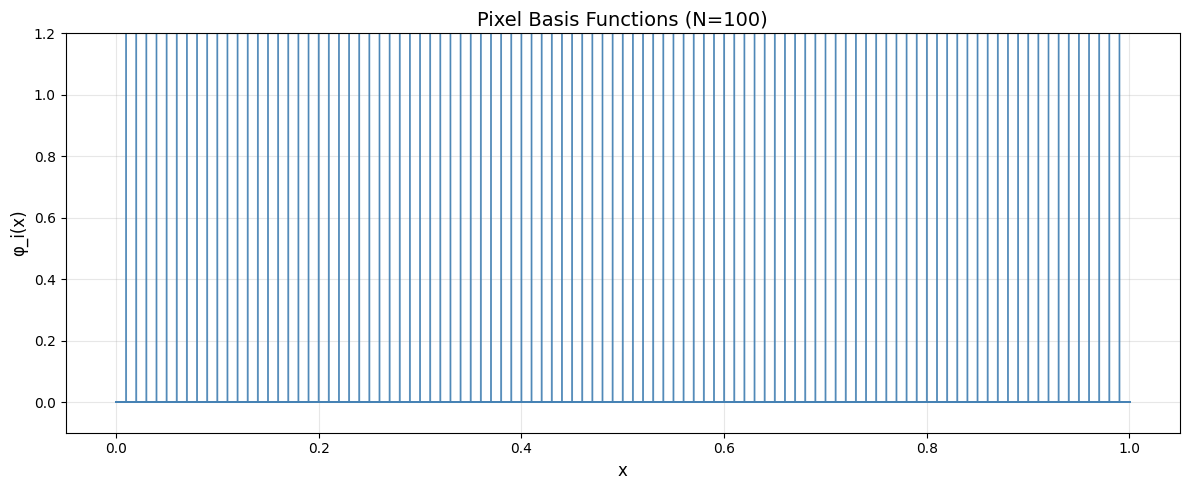

Pixel Basis Summary:
  Number of basis functions: 100
  Domain: [0.0, 1.0]
  Width of each pixel: 0.0100


In [22]:
# Plot all pixel basis functions
fig, ax = plt.subplots(figsize=(12, 5))

x_plot = np.linspace(function_domain.a, function_domain.b, 2000)
for i in range(N):
    phi_i = M.get_basis_function(i)
    y_plot = np.array([phi_i(x) for x in x_plot])
    ax.plot(x_plot, y_plot, color='steelblue', linewidth=1.0, alpha=0.8)

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('φ_i(x)', fontsize=12)
ax.set_title(f'Pixel Basis Functions (N={N})', fontsize=14)
ax.set_ylim([-0.1, 1.2])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Pixel Basis Summary:")
print(f"  Number of basis functions: {N}")
print(f"  Domain: [{function_domain.a}, {function_domain.b}]")
print(f"  Width of each pixel: {pixel_width:.4f}")


# Continuous vs Discrete Property Linear Inference

We now compare **PLI in the continuous and discrete settings** following the
theory in `discretization.txt`.

## Prior covariance

A valid Gaussian measure on the infinite-dimensional Lebesgue space
$\mathcal{M} = L^2([0,1])$ requires a **trace-class** covariance operator
$C_0 : \mathcal{M} \to \mathcal{M}$.  We use the Whittle–Matérn choice

$$C_0 = (\kappa^2 I - \Delta)^{-1},$$

whose eigenvalues $(\kappa^2 + n^2\pi^2)^{-1} \sim n^{-2}$ are summable in 1D
(trace class).  Samples lie in $H^1([0,1])$.  The precision operator is
$C_0^{-1} = \kappa^2 I - \Delta$.

The **discrete prior covariance matrix** on the pixel coefficient space
$\mathbb{V}_N \cong \mathbb{R}^N$ is the pullback of $C_0$ through the
coordinate-inclusion map $\Pi^* : \mathbb{R}^N \to \mathcal{M}_N$:

$$\mathbf{C}_0 = \Pi\, C_0\, \Pi^*$$

where $\Pi = \texttt{M.to\_components}$ is the analysis operator and
$\Pi^* = \texttt{M.from\_components}$ is the synthesis operator.
Since `LinearOperator.matrix(dense=True)` computes exactly
$\Pi \circ L \circ \Pi^*$ column by column (applying $L$ to each basis
function and projecting back), we obtain $\mathbf{C}_0$ simply by calling
`.matrix()` on the continuous operator $C_0$.

## Three PLI strategies

1. **Continuous PLI** (gold standard): Bayesian inference with
   $G : \mathcal{M} \to \mathcal{D}$ and prior $\mathcal{N}(0, C_0)$ on
   $\mathcal{M}$.  Property posterior via $\mathcal{T} : \mathcal{M} \to \mathcal{P}$.

2. **Correct discrete PLI**: The coefficient space
   $\mathbb{V}_N = \mathtt{MassWeightedHilbertSpace}(\mathbb{R}^N, M, M^{-1})$
   carries the mass-matrix inner product $\langle\alpha,\beta\rangle_{\mathbb{V}_N} = \alpha^\top M \beta$
   (theory §2.2, eq. 7).  Operators $\mathbf{G}: \mathbb{V}_N \to \mathcal{D}$ and
   $\mathbf{T}: \mathbb{V}_N \to \mathcal{P}$ are lifted via
   `LinearOperator.from_formal_adjoint`, so that their adjoints
   $\mathbf{G}^* = M^{-1}\mathbf{G}^\top$ and $\mathbf{T}^* = M^{-1}\mathbf{T}^\top$
   emerge automatically from the space geometry.  The prior is
   $\mathcal{N}(0, \mathbf{C}_0 = \Pi C_0 \Pi^*)$ on $\mathbb{V}_N$.

3. **Naive discrete PLI** (wrong, for comparison): Uses
   `G @ M.coordinate_inclusion` (adjoint = plain transpose, omitting
   $M^{-1}$) and a white-noise prior $\sigma^2 \mathbf{I}$, ignoring
   both the mass-matrix structure and spatial correlation.


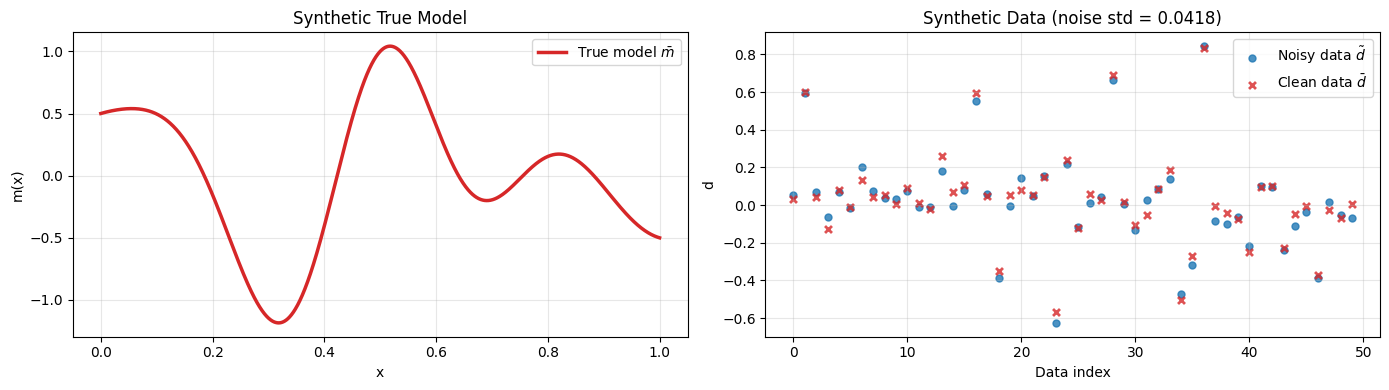

SNR ≈ 20.0


In [23]:
# =============================================================================
# SYNTHETIC TRUE MODEL AND DATA
# =============================================================================
# We create a known ground-truth model m_bar so that we can check how well
# each PLI variant recovers the true properties T(m_bar).

x = np.linspace(function_domain.a, function_domain.b, 2000)

# True model: a smooth sine-Gaussian combination that is well represented in
# the finite pixel basis but has sub-pixel structure to make the comparison
# non-trivial.
from intervalinf.core.functions import Function
m_bar = Function(
    M,
    evaluate_callable=lambda x: (
        np.sin(5 * np.pi * x) * np.exp(-10 * (x - 0.5)**2) +
        0.5 * np.cos(3 * np.pi * x)
    )
)

# Noiseless synthetic data: d_bar = G(m_bar)
d_bar = G(m_bar)

# Additive Gaussian noise: d_tilde = d_bar + eta, eta ~ N(0, noise_std^2 * I)
noise_std = 0.05 * np.max(np.abs(d_bar))   # 5 % of signal amplitude
np.random.seed(42)                          # reproducibility
d_tilde = d_bar + np.random.normal(0, noise_std, d_bar.shape)

# True properties p_bar = T(m_bar): these are the target values we want to infer.
p_bar = T(m_bar)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(x, m_bar.evaluate(x), color='tab:red', linewidth=2.5, label=r'True model $\bar m$')
axes[0].set_xlabel('x');  axes[0].set_ylabel('m(x)')
axes[0].set_title('Synthetic True Model');  axes[0].legend();  axes[0].grid(True, alpha=0.3)

axes[1].scatter(np.arange(N_d), d_tilde, s=25, alpha=0.8, label='Noisy data $\\tilde d$', color='tab:blue')
axes[1].scatter(np.arange(N_d), d_bar,  s=25, alpha=0.8, marker='x', linewidths=2,
                label='Clean data $\\bar d$', color='tab:red')
axes[1].set_xlabel('Data index');  axes[1].set_ylabel('d')
axes[1].set_title(f'Synthetic Data (noise std = {noise_std:.4f})')
axes[1].legend();  axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f"SNR ≈ {np.max(np.abs(d_bar)) / noise_std:.1f}")

In [24]:

# =============================================================================
# PRIOR AND DATA-ERROR MEASURES — PROPER FUNCTION-SPACE PRIOR
# =============================================================================
#
# A Gaussian measure on an infinite-dimensional Hilbert space M requires a
# covariance operator  C0 : M → M  that is:
#   (a) symmetric positive definite
#   (b) TRACE-CLASS  (so that the measure is non-degenerate on M)
#
# We use a Bessel–Sobolev / Whittle–Matérn covariance:
#
#       C0 = (kappa^2 I − Δ)^{−1}
#
# Properties:
#   • Self-adjoint and positive definite: eigenvalues (kappa^2 + n^2π^2)^{−1} > 0
#   • Trace class in 1D: Σ (kappa^2 + n^2π^2)^{-1} ~ Σ n^{-2} < ∞    ✓
#   • Samples lie in H^1([0,1]) (one weak derivative)
#   • kappa controls correlation length:  larger kappa → shorter correlations
#
kappa = 3.0   # correlation parameter; correlation length ≈ 1/kappa ≈ 0.33

bc_neumann = BoundaryConditions('neumann', left=0.0, right=0.0)

# Laplacian L = −d²/dx² with Neumann BCs, used to supply the eigenspectrum.
laplacian_op = Laplacian(M, bc_neumann, method='spectral', dofs=256)

# ---------------------------------------------------------------------------
# CONTINUOUS PRIOR
# ---------------------------------------------------------------------------
# Covariance half-factor:   C0^{1/2} = (kappa^2 I − Δ)^{−1/2}
#   BesselSobolevInverse(s=1) scales eigenvalue λ by (k^2 + λ)^{-1/2}
# Precision half-factor:    C0^{-1/2} = (kappa^2 I − Δ)^{+1/2}
#   BesselSobolev(s=1) scales eigenvalue λ by (k^2 + λ)^{+1/2}
C0_half     = BesselSobolevInverse(M, M, k=kappa, s=1.0, L=laplacian_op, dofs=N)
C0_inv_half = BesselSobolev    (M, M, k=kappa, s=1.0, L=laplacian_op, dofs=N)

# N(0, C0) on M, where C0 = C0_half @ C0_half^* = (kappa^2 I − Δ)^{-1}
prior_continuous = GaussianMeasure(
    covariance_factor=C0_half,
    inverse_covariance_factor=C0_inv_half,
)

# ---------------------------------------------------------------------------
# DISCRETE PRIOR — on V_N = MassWeightedHilbertSpace(R^N, M)
# ---------------------------------------------------------------------------
# The covariance matrix (Galerkin matrix of the continuous C0) is:
#
#     C0_mat_disc = Pi @ C0 @ Pi^*
#
# GaussianMeasure.from_covariance_matrix(V_N, K) creates a measure whose
# covariance operator acts as  M^{-1} K  on component vectors.
# To obtain a covariance operator that acts as C0_mat_disc, we must pass
#
#     K = M_mat @ C0_mat_disc      (Galerkin form on V_N)
#
# Then covariance = M^{-1} (M @ C0_mat_disc) = C0_mat_disc  ✓

C0_full = BesselSobolevInverse(M, M, k=kappa, s=2.0, L=laplacian_op, dofs=N)
C0_mat_disc = C0_full.matrix(dense=True, parallel=True, n_jobs=parallel_cfg.n_jobs)
C0_mat_disc = 0.5 * (C0_mat_disc + C0_mat_disc.T)  # symmetrize numerical noise

prior_discrete = GaussianMeasure.from_covariance_matrix(
    V_N,
    C0_mat_disc,     # Galerkin form: covariance acts as M^{-1}(M C0) = C0_mat_disc
)

# ---------------------------------------------------------------------------
# NAIVE DISCRETE PRIOR — independent white noise on R^N (intentionally wrong)
# ---------------------------------------------------------------------------
# C0_naive = sigma^2 I : treats pixel coefficients as iid, ignores both the
# mass matrix and any spatial correlation.
sigma_prior = 0.05
C0_naive = sigma_prior**2 * np.eye(N)

prior_naive = GaussianMeasure.from_covariance_matrix(EuclideanSpace(N), C0_naive)

# ---------------------------------------------------------------------------
# DATA ERROR MEASURE: N(0, noise_std^2 · I_{N_d})
# ---------------------------------------------------------------------------
data_error = GaussianMeasure.from_standard_deviations(
    D,
    noise_std * np.ones(N_d),
)

solver = CholeskySolver()

print(f"Continuous prior: C0 = (kappa^2 I − Δ)^{{-1}},  kappa = {kappa}")
print(f"C0_mat_disc diagonal mean      : {np.diag(C0_mat_disc).mean():.6f}")
print(f"C0_mat_disc trace (total var)  : {np.trace(C0_mat_disc):.4f}")


Continuous prior: C0 = (kappa^2 I − Δ)^{-1},  kappa = 3.0
C0_mat_disc diagonal mean      : 0.002217
C0_mat_disc trace (total var)  : 0.2217


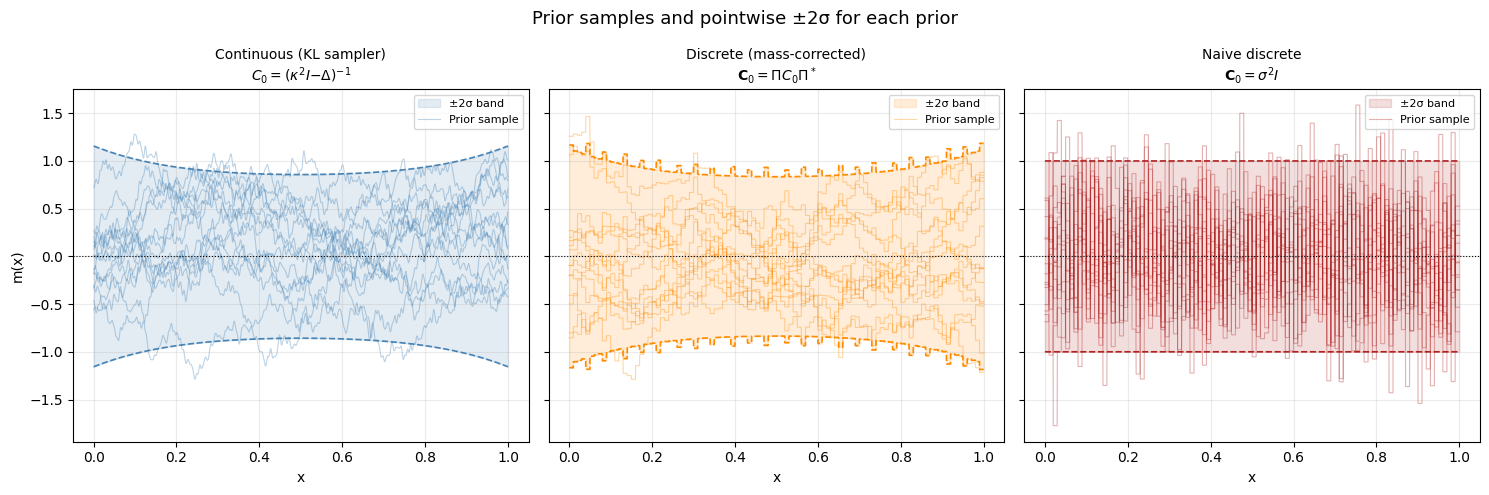

Prior comparison:
  Continuous  trace = 0.2220
  Discrete    trace = 0.2217  (should match continuous)
  Naive       trace = 0.2500  (sigma^2 * N  — depends on N!)


In [26]:

# =============================================================================
# PRIOR VISUALISATION — samples + pointwise ±2σ for all three priors
# =============================================================================
# To compare fairly:
#   • Continuous samples use the KL sampler directly on the covariance operator
#     C0 — this is truly mesh-independent: samples live in H^1([0,1]) and are
#     sums of smooth Neumann cosines, with no reference to the pixel basis.
#   • Discrete/naive samples draw coefficient vectors and expand in the pixel
#     basis via M.from_components, giving piecewise-constant functions.
#
# CONTINUOUS PRIOR (KL sampler)
#   u = sum_k sqrt(lambda_k) * xi_k * psi_k,  xi_k ~ N(0,1)
#
# DISCRETE PRIOR
#   alpha ~ N(0, C0_mat_disc) via Cholesky; m = M.from_components(alpha).
#
# NAIVE DISCRETE PRIOR
#   alpha ~ N(0, sigma^2 I); m = M.from_components(alpha).
#
# POINTWISE VARIANCE
#   Because the pixel basis is orthonormal (mass matrix = I), the coefficient
#   std vector maps directly into a pointwise std function via from_components:
#
#     std_disc(x) = M.from_components(sqrt(diag(C0_mat_disc)))(x)
#     std_naive(x) = M.from_components(sigma_prior * ones)(x)
#
#   For the continuous prior, the KL sum gives the exact pointwise variance.

from intervalinf.sampling.kl_sampler import KLSampler

np.random.seed(0)
N_samples  = 15
x_vis      = np.linspace(function_domain.a, function_domain.b, 2000)

# ── KL sampler for the continuous prior ──────────────────────────────────────
kl_sampler = KLSampler(C0_full, n_modes=300, rng=np.random.default_rng(0))

# ── Cholesky factor of the discrete covariance ───────────────────────────────
L_chol = np.linalg.cholesky(C0_mat_disc)

# ── Pointwise standard deviation ─────────────────────────────────────────────
# Continuous: KL sum   Var(x) = sum_k  lambda_k * psi_k(x)^2
var_cont = kl_sampler.variance_function(x_vis)
std_cont = np.sqrt(var_cont)

# Discrete: std of each coefficient → function via from_components
std_disc = M.from_components(np.sqrt(np.diag(C0_mat_disc))).evaluate(x_vis)

# Naive: constant coefficient std sigma_prior → function via from_components
std_naive_arr = M.from_components(sigma_prior * np.ones(N)).evaluate(x_vis)

# ── Draw samples ─────────────────────────────────────────────────────────────
samples_cont  = []
samples_disc  = []
samples_naive = []

rng_disc = np.random.default_rng(1)

for _ in range(N_samples):
    # --- Continuous sample (mesh-independent KL expansion) ---
    s_cont = kl_sampler.sample()
    samples_cont.append(s_cont.evaluate(x_vis))

    # --- Discrete (mass-corrected) sample ---
    alpha  = L_chol @ rng_disc.standard_normal(N)  # alpha ~ N(0, C0_mat_disc)
    m_disc = M.from_components(alpha)
    samples_disc.append(m_disc.evaluate(x_vis))

    # --- Naive discrete sample ---
    alpha_n  = sigma_prior * rng_disc.standard_normal(N)
    m_naive  = M.from_components(alpha_n)
    samples_naive.append(m_naive.evaluate(x_vis))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle("Prior samples and pointwise ±2σ for each prior", fontsize=13)

configs = [
    (axes[0], samples_cont,  std_cont,       'steelblue',  "Continuous (KL sampler)\n$C_0=(\\kappa^2 I{-}\\Delta)^{-1}$"),
    (axes[1], samples_disc,  std_disc,        'darkorange', "Discrete (mass-corrected)\n$\\mathbf{C}_0 = \\Pi C_0 \\Pi^*$"),
    (axes[2], samples_naive, std_naive_arr,   'firebrick',  "Naive discrete\n$\\mathbf{C}_0 = \\sigma^2 I$"),
]

for ax, samps, std_arr, col, title in configs:
    ax.fill_between(x_vis, -2*std_arr, 2*std_arr,
                    color=col, alpha=0.15, label='±2σ band')
    ax.plot(x_vis,  2*std_arr, color=col, lw=1.2, ls='--')
    ax.plot(x_vis, -2*std_arr, color=col, lw=1.2, ls='--')
    for k, s in enumerate(samps):
        ax.plot(x_vis, s, color=col, alpha=0.35, lw=0.8,
                label='Prior sample' if k == 0 else '')
    ax.axhline(0, color='black', lw=0.8, ls=':')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel('m(x)')
plt.tight_layout()
plt.show()

print("Prior comparison:")
print(f"  Continuous  trace = {np.sum([C0_full.get_eigenvalue(k) for k in range(N)]):.4f}")
print(f"  Discrete    trace = {np.trace(C0_mat_disc):.4f}  (should match continuous)")
print(f"  Naive       trace = {sigma_prior**2 * N:.4f}  (sigma^2 * N  — depends on N!)")


In [27]:
# =============================================================================
# STRATEGY 1 — CONTINUOUS PLI
# =============================================================================
# All operations happen in the infinite-dimensional Lebesgue space M.
# The forward operator G : M → D is used directly; pygeoinf computes its
# Hilbert-space adjoint G* : D → M automatically via the Riesz maps of M and D.
#
# Bayesian update (Woodbury form):
#   K  = C0 G* (G C0 G* + C_D)^{-1}              (Kalman gain)
#   ~m = m0 + K (d_tilde - G m0)                  (posterior mean)
#   C_M = C0 - K G C0                              (posterior covariance)
#
# Then push through T to obtain the property posterior:
#   ~p  = T(~m)
#   C_P = T C_M T*
#
# This is the "gold standard" — the result we want the discrete version to match.

forward_problem_cont = LinearForwardProblem(
    G,                # continuous forward operator G : M → D
    data_error_measure=data_error,
)

bayes_cont = LinearBayesianInversion(forward_problem_cont, prior_continuous)

# Compute model posterior p(m | d_tilde)
mu_model_cont = bayes_cont.model_posterior_measure(d_tilde, solver)

# Push model posterior through the continuous property map T : M → P.
# GaussianMeasure.affine_mapping(operator=T) computes:
#   mean:  T(~m)
#   cov:   T C_M T*
mu_prop_cont = mu_model_cont.affine_mapping(operator=T)

# Extract mean and standard deviation for plotting
p_mean_cont = mu_prop_cont.expectation          # shape (N_p,)
C_prop_cont = mu_prop_cont.covariance.matrix(dense=True, galerkin=True)  # (N_p, N_p)
p_std_cont  = np.sqrt(np.diag(C_prop_cont))     # marginal standard deviations

print("Continuous PLI complete.")
print(f"  Property posterior mean  in [{p_mean_cont.min():.4f}, {p_mean_cont.max():.4f}]")
print(f"  Property posterior std   in [{p_std_cont.min():.4f}, {p_std_cont.max():.4f}]")

Continuous PLI complete.
  Property posterior mean  in [-0.9250, 0.7919]
  Property posterior std   in [0.0318, 0.1046]


In [28]:

# =============================================================================
# STRATEGY 2 — MASS-CORRECTED DISCRETE PLI
# =============================================================================
# The coefficient space V_N = MassWeightedHilbertSpace(R^N, M) carries the
# inner product  <α, β>_{V_N} = α^T M β  (theory §2.2, eq. 7).
#
# G_discretized : V_N → D   adjoint = M^{-1} G^T   ← emerges from V_N geometry
# T_discretized : V_N → P   adjoint = M^{-1} T^T   ← emerges from V_N geometry
#
# (constructed in cell 6 via LinearOperator.from_formal_adjoint — no manual M^{-1})
#
# The discrete prior on V_N has covariance = C0_mat_disc = Pi C0 Pi^*
# (constructed in cell 10: from_covariance_matrix(V_N, M_mat @ C0_mat_disc))

forward_problem_disc = LinearForwardProblem(
    G_discretized,          # G_d : V_N → R^{N_d}, adjoint = M^{-1} G^T
    data_error_measure=data_error,
)

bayes_disc = LinearBayesianInversion(forward_problem_disc, prior_discrete)

mu_model_disc = bayes_disc.model_posterior_measure(d_tilde, solver)

# Push through T_discretized : V_N → R^{N_p} (adjoint = M^{-1} T^T)
mu_prop_disc = mu_model_disc.affine_mapping(operator=T_discretized)

p_mean_disc = mu_prop_disc.expectation
C_prop_disc = mu_prop_disc.covariance.matrix(dense=True)
p_std_disc  = np.sqrt(np.diag(C_prop_disc))

print("Mass-corrected discrete PLI complete.")
print(f"  Property posterior mean  in [{p_mean_disc.min():.4f}, {p_mean_disc.max():.4f}]")
print(f"  Property posterior std   in [{p_std_disc.min():.4f}, {p_std_disc.max():.4f}]")


Mass-corrected discrete PLI complete.
  Property posterior mean  in [-0.9208, 0.7917]
  Property posterior std   in [0.0313, 0.1038]


In [29]:
# =============================================================================
# STRATEGY 3 — NAIVE DISCRETE PLI  (intentionally incorrect)
# =============================================================================
# A common mistake is to use the composition  G_naive = G @ M.coordinate_inclusion
# as the discretized forward operator without realising that:
#   (a) the coordinate inclusion Pi : R^N → M maps coefficient vectors into M, so
#       G_naive : R^N → R^{N_d};
#   (b) pygeoinf's automatic adjoint for this composition is computed as
#       Pi^T G^T, which is the correct adjoint *only if* Pi^T = Pi^* is evaluated
#       with the standard Euclidean inner product on R^N — i.e. it assumes M = I.
#   (c) we also use a naive prior C0_naive = sigma^2 I, which corresponds to
#       treating the pixel coefficients as independent with unit variance,
#       ignoring the pixel width entirely.
#
# The result will differ from the continuous answer whenever pixel_width ≠ 1
# (i.e. always in practice), because the mass-matrix correction is omitted.

G_naive = G @ M.coordinate_inclusion    # G_mat @ c, adjoint = G_mat^T (wrong: misses M^{-1})
T_naive = T @ M.coordinate_inclusion    # T_mat @ c, adjoint = T_mat^T

forward_problem_naive = LinearForwardProblem(
    G_naive,
    data_error_measure=data_error,
)

bayes_naive = LinearBayesianInversion(forward_problem_naive, prior_naive)

mu_model_naive = bayes_naive.model_posterior_measure(d_tilde, solver)

mu_prop_naive = mu_model_naive.affine_mapping(operator=T_naive)

p_mean_naive = mu_prop_naive.expectation
C_prop_naive = mu_prop_naive.covariance.matrix(dense=True)
p_std_naive  = np.sqrt(np.diag(C_prop_naive))

print("Naive discrete PLI complete.")
print(f"  Property posterior mean  in [{p_mean_naive.min():.4f}, {p_mean_naive.max():.4f}]")
print(f"  Property posterior std   in [{p_std_naive.min():.4f}, {p_std_naive.max():.4f}]")

Naive discrete PLI complete.
  Property posterior mean  in [-0.7928, 0.6043]
  Property posterior std   in [0.0417, 0.1064]


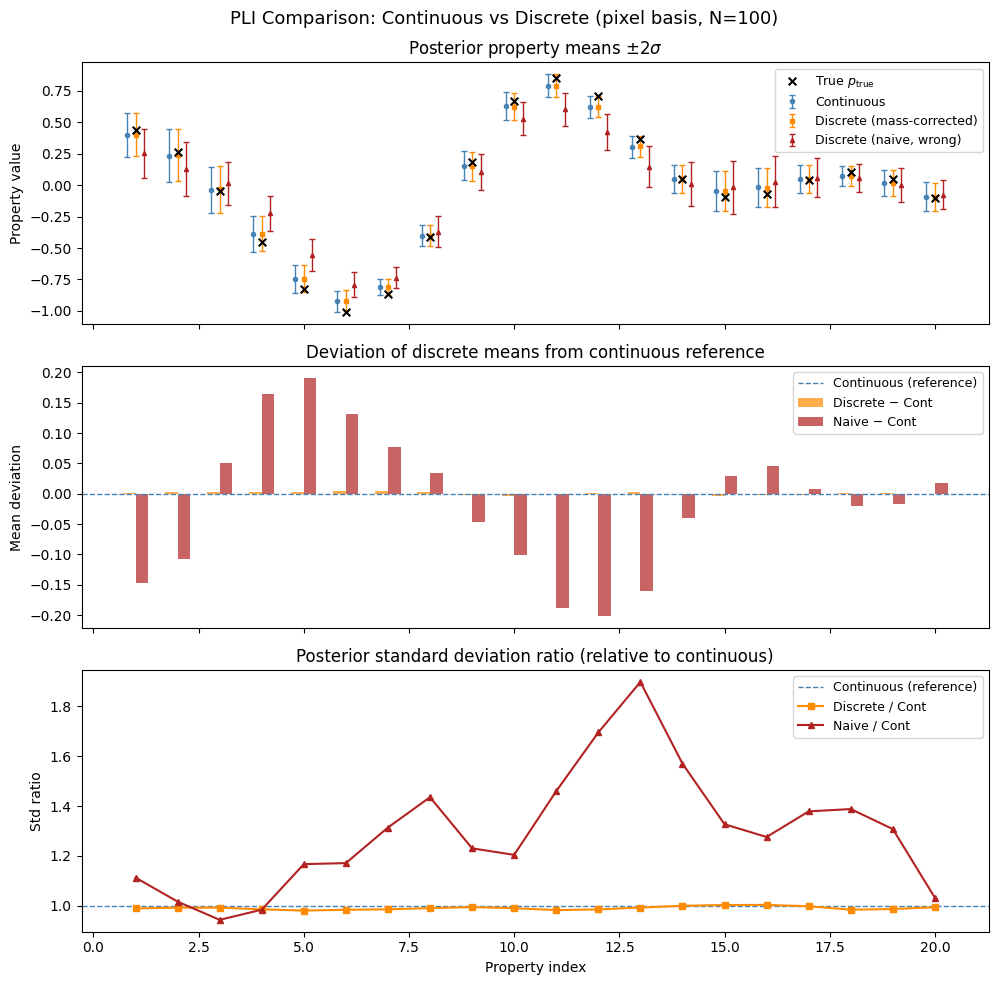

RMS deviation (discrete vs continuous) : 2.4819e-03
RMS deviation (naive    vs continuous) : 1.1034e-01

Mean std ratio (discrete / continuous) : 0.9913
Mean std ratio (naive    / continuous) : 1.2956


In [30]:
# =============================================================================
# COMPARISON VISUALISATION
# =============================================================================
# Three panels:
#   Top   : property posterior mean ± 2σ for each strategy + true value p_bar.
#   Middle: mean deviation from the continuous (reference) result.
#   Bottom: std ratio relative to the continuous result
#           (> 1 = over-estimated uncertainty, < 1 = under-estimated).

# Property index axis (1-based for readability)
idx = np.arange(1, N_p + 1)

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
fig.suptitle("PLI Comparison: Continuous vs Discrete (pixel basis, N=100)", fontsize=13)

# ─── Panel 1: posterior means with ±2σ shading ────────────────────────────────
ax = axes[0]
ax.errorbar(idx - 0.2, p_mean_cont,  yerr=2*p_std_cont,  fmt='o', ms=3,
            color='steelblue',  elinewidth=1, capsize=2, label='Continuous')
ax.errorbar(idx,        p_mean_disc,  yerr=2*p_std_disc,  fmt='s', ms=3,
            color='darkorange', elinewidth=1, capsize=2, label='Discrete (mass-corrected)')
ax.errorbar(idx + 0.2, p_mean_naive, yerr=2*p_std_naive, fmt='^', ms=3,
            color='firebrick',  elinewidth=1, capsize=2, label='Discrete (naive, wrong)')
ax.scatter(idx, p_bar, marker='x', color='black', s=30, zorder=5, label='True $p_{\\rm true}$')
ax.set_ylabel("Property value")
ax.set_title("Posterior property means $\\pm 2\\sigma$")
ax.legend(fontsize=9, loc='upper right')

# ─── Panel 2: deviation from continuous reference ────────────────────────────
ax = axes[1]
ax.axhline(0, color='steelblue', lw=1, ls='--', label='Continuous (reference)')
ax.bar(idx - 0.15, p_mean_disc  - p_mean_cont, width=0.3,
       color='darkorange', alpha=0.7, label='Discrete − Cont')
ax.bar(idx + 0.15, p_mean_naive - p_mean_cont, width=0.3,
       color='firebrick',  alpha=0.7, label='Naive − Cont')
ax.set_ylabel("Mean deviation")
ax.set_title("Deviation of discrete means from continuous reference")
ax.legend(fontsize=9, loc='upper right')

# ─── Panel 3: std ratio relative to continuous ───────────────────────────────
ax = axes[2]
ax.axhline(1.0, color='steelblue', lw=1, ls='--', label='Continuous (reference)')
ax.plot(idx, p_std_disc  / p_std_cont, 's-', color='darkorange', ms=4,
        label='Discrete / Cont')
ax.plot(idx, p_std_naive / p_std_cont, '^-', color='firebrick',  ms=4,
        label='Naive / Cont')
ax.set_xlabel("Property index")
ax.set_ylabel("Std ratio")
ax.set_title("Posterior standard deviation ratio (relative to continuous)")
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

# ─── Summary statistics ───────────────────────────────────────────────────────
rms_disc  = np.sqrt(np.mean((p_mean_disc  - p_mean_cont)**2))
rms_naive = np.sqrt(np.mean((p_mean_naive - p_mean_cont)**2))
print(f"RMS deviation (discrete vs continuous) : {rms_disc:.4e}")
print(f"RMS deviation (naive    vs continuous) : {rms_naive:.4e}")
print()
print(f"Mean std ratio (discrete / continuous) : {np.mean(p_std_disc  / p_std_cont):.4f}")
print(f"Mean std ratio (naive    / continuous) : {np.mean(p_std_naive / p_std_cont):.4f}")